# Laboratorio de Clustering - Dataset Wikipedia
Vamos a usar el dataset de https://archive.ics.uci.edu/ml/datasets/wiki4he, que son dos encuestas de uso de Wikipedia en distintas universidades

In [ ]:
# Detección de entorno (para instalar dependencias solo en Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules

# Gráficos
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8,6)
plt.rcParams['font.size'] = 16
import seaborn as sns

# Números y Datos
import numpy as np
import pandas as pd
pd.set_option('future.infer_string', False) # Necesario para evitar errores con Gower y los nuevos dtypes de pandas 3

# Archivos
import os
import urllib.request
import zipfile

# Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

In [ ]:
# Descargamos el dataset de UCI.
url = 'https://archive.ics.uci.edu/static/public/334/wiki4he.zip'
if not os.path.exists('wiki4HE.csv'):
    urllib.request.urlretrieve(url, 'wiki4he.zip')
    with zipfile.ZipFile('wiki4he.zip') as z:
        z.extractall('.')

In [ ]:
df = pd.read_csv('wiki4HE.csv',sep=';')
df.head(10)

,AGE,GENDER,DOMAIN,PhD,YEARSEXP,UNIVERSITY,UOC_POSITION,OTHER_POSITION,OTHERSTATUS,USERWIKI,...,BI2,Inc1,Inc2,Inc3,Inc4,Exp1,Exp2,Exp3,Exp4,Exp5
0,40,0,2,1,14,1,2,?,?,0,...,3,5,5,5,5,4,4,4,1,2
1,42,0,5,1,18,1,2,?,?,0,...,2,4,4,3,4,2,2,4,2,4
2,37,0,4,1,13,1,3,?,?,0,...,1,5,3,5,5,2,2,2,1,3
3,40,0,4,0,13,1,3,?,?,0,...,3,3,4,4,3,4,4,3,3,4
4,51,0,6,0,8,1,3,?,?,1,...,5,5,5,4,4,5,5,5,4,4
5,47,0,4,0,17,1,3,?,?,0,...,4,5,3,2,4,4,3,4,1,4
6,43,0,4,0,11,1,3,?,?,0,...,4,4,4,4,1,4,5,5,2,2
7,55,0,6,0,12,1,3,?,?,0,...,4,3,3,3,3,4,4,3,1,4
8,54,0,1,1,14,1,2,?,?,0,...,3,5,5,4,2,5,5,5,1,1
9,50,0,4,1,25,1,2,?,?,0,...,5,5,5,5,5,4,5,2,1,1


In [ ]:
df.shape

(913, 53)

In [ ]:
df.columns

Index(['AGE', 'GENDER', 'DOMAIN', 'PhD', 'YEARSEXP', 'UNIVERSITY',
       'UOC_POSITION', 'OTHER_POSITION', 'OTHERSTATUS', 'USERWIKI', 'PU1',
       'PU2', 'PU3', 'PEU1', 'PEU2', 'PEU3', 'ENJ1', 'ENJ2', 'Qu1', 'Qu2',
       'Qu3', 'Qu4', 'Qu5', 'Vis1', 'Vis2', 'Vis3', 'Im1', 'Im2', 'Im3', 'SA1',
       'SA2', 'SA3', 'Use1', 'Use2', 'Use3', 'Use4', 'Use5', 'Pf1', 'Pf2',
       'Pf3', 'JR1', 'JR2', 'BI1', 'BI2', 'Inc1', 'Inc2', 'Inc3', 'Inc4',
       'Exp1', 'Exp2', 'Exp3', 'Exp4', 'Exp5'],
      dtype='object')

In [ ]:
df.describe()

,AGE,GENDER,PhD,UNIVERSITY
count,913.000000,913.000000,913.000000,913.000000
mean,42.246440,0.424973,0.464403,1.123768
std,8.058418,0.494610,0.499005,0.329497
min,23.000000,0.000000,0.000000,1.000000
25%,36.000000,0.000000,0.000000,1.000000
50%,42.000000,0.000000,0.000000,1.000000
75%,47.000000,1.000000,1.000000,1.000000
max,69.000000,1.000000,1.000000,2.000000


In [ ]:
df.dtypes

,0
AGE,int64
GENDER,int64
DOMAIN,object
PhD,int64
YEARSEXP,object
UNIVERSITY,int64
UOC_POSITION,object
OTHER_POSITION,object
OTHERSTATUS,object
USERWIKI,object


# Limpieza y preparación de los datos

## Datos faltantes
Mirando `df.head()` y los tipos de arriba vemos dos cosas: los valores faltantes están codificados con un signo de pregunta `'?'`, y eso obliga a pandas a leer como **texto** columnas que en realidad son numéricas (por ejemplo `YEARSEXP`).

La forma correcta de manejarlo es indicarle a pandas, al leer el archivo, que `'?'` representa un dato faltante (`na_values='?'`). Así esos valores pasan a ser `NaN` y los tipos de cada columna se infieren correctamente.

Podemos primero explorar cuántos datos faltantes hay por columna. Recuerden que hay ~900 registros.

In [ ]:
# Releemos indicándole a pandas que '?' codifica faltantes: pasan a NaN y, de paso,
# las columnas que son numéricas (p. ej. YEARSEXP) se infieren como números y no como texto.
df = pd.read_csv('wiki4HE.csv', sep=';', na_values='?')
df.isna().sum().sort_values(ascending=False).head(15)

,0
OTHERSTATUS,540
OTHER_POSITION,261
Vis2,117
UOC_POSITION,113
PEU3,97
Vis1,72
Im3,57
JR2,53
BI2,43
Inc4,42


Luego, podemos explorar si todos los datos faltantes están en algunas filas en particular. Recuerden que hay ~50 columnas.

<Axes: >

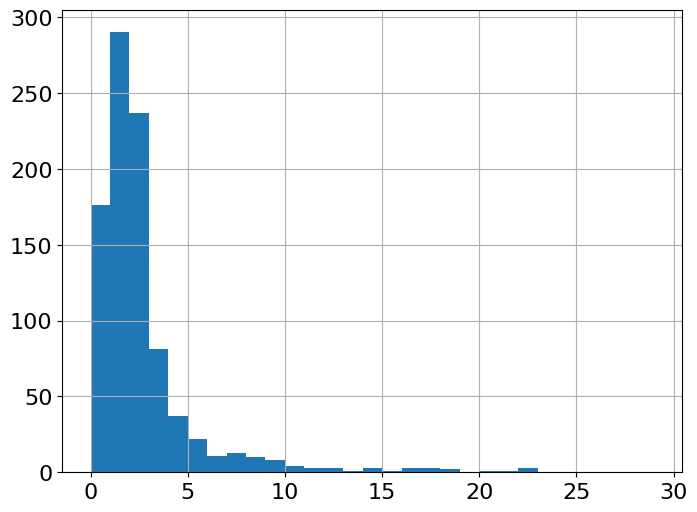

In [ ]:
df.isna().sum(axis=1).hist(bins=range(0,30))

Finalmente, podemos ver cuántos datos hay sin ningún dato faltante.

In [ ]:
print('Hay %d registros sin datos faltantes.' % df.notna().all(axis=1).sum())

Hay 176 registros sin datos faltantes.


Hay pocas variables que concentran muchos valores faltantes. Para simplificar el análisis no vamos a aplicar técnicas de imputación de datos faltantes, pero haremos algunos cambios en el dataset.

La variable OTHER_POSITION sólo tiene sentido para los docentes que tienen otra posición además de la que tienen en UOC.
Las preguntas Vis2 y Peu3 solo deberían ser respondidos por quienes editan artículos en Wikipedia, o conocen a alguien que lo haga.
Podemos eliminar estas variables.

In [ ]:
df = df.drop(columns=['OTHER_POSITION','Vis2','PEU3'])
print('Hay %d registros sin datos faltantes.' % df.notna().all(axis=1).sum())

Hay 188 registros sin datos faltantes.


En una situación de trabajo real, habría que continuar el análisis de los datos faltantes, y considerar aplicar alguna técnica de imputación. Nosotros, para simplificar, nos vamos a quedar solo con los registros completos.

**Atención al costo:** así pasamos de 913 a 188 registros, es decir descartamos cerca del **79 %** de la muestra (y probablemente no de forma aleatoria). En un problema real una pérdida así sería difícil de justificar sin imputar.

Vamos a separar los datos profesionales y demográficos de los encuestados.

In [ ]:
df = df.dropna()
df.shape

(188, 50)

In [ ]:
df.head()

,AGE,GENDER,DOMAIN,PhD,YEARSEXP,UNIVERSITY,UOC_POSITION,OTHERSTATUS,USERWIKI,PU1,...,BI2,Inc1,Inc2,Inc3,Inc4,Exp1,Exp2,Exp3,Exp4,Exp5
148,43,0,6.0,0,7.0,1,6.0,7.0,0.0,5.0,...,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,2.0,4.0
149,39,0,6.0,0,15.0,1,6.0,3.0,0.0,3.0,...,3.0,4.0,4.0,3.0,4.0,2.0,3.0,4.0,1.0,2.0
160,43,0,5.0,1,20.0,1,6.0,2.0,0.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,1.0,1.0
164,44,0,1.0,1,20.0,1,6.0,2.0,0.0,3.0,...,3.0,3.0,5.0,3.0,3.0,2.0,3.0,1.0,1.0,1.0
165,44,0,6.0,0,20.0,1,6.0,7.0,0.0,4.0,...,3.0,4.0,4.0,5.0,3.0,4.0,4.0,4.0,2.0,3.0


In [ ]:
campos_meta = ['AGE', 'GENDER', 'DOMAIN', 'PhD', 'YEARSEXP', 'UNIVERSITY',
                                       'UOC_POSITION', 'OTHERSTATUS', 'USERWIKI']
meta = df[campos_meta].copy()
encu = df.drop(columns=campos_meta).copy()

# Metadata
Arrancamos con los datos de los encuestados

## Limpieza y preparación de los datos
Vamos a corregir las categorias (en el caso que corresponda) y el tipo de datos (Numerico, Booleano o logico, y Categorico)

In [ ]:
meta.dtypes

,0
AGE,int64
GENDER,int64
DOMAIN,float64
PhD,int64
YEARSEXP,float64
UNIVERSITY,int64
UOC_POSITION,float64
OTHERSTATUS,float64
USERWIKI,float64


Las edades (`AGE`) y los años de experiencia (`YEARSEXP`) son numéricas... ok

Hay otras dos variables que deberían estar codificadas como de tipo lógico, PhD y USERWIKI. Las siguientes variables deberían ser de tipo factor: GENDER, DOMAIN, UOC_POSITION, UNIVERSITY y OTHERSTATUS.

Estas conversiones son importantes para evitar más adelante calcular, por ejemplo, distancias Euclídeas entre sexos o entre dominios de trabajo.

In [ ]:
# .map convierte cada código numérico a su etiqueta de texto, que es lo que Gower
# interpreta como variable categórica.
meta['UNIVERSITY'] = meta['UNIVERSITY'].map({1: 'UOC', 2: 'UPF'})
meta['GENDER'] = meta['GENDER'].map({0: 'M', 1: 'F'})
meta['PhD'] = meta['PhD'].map({0: 'N', 1: 'Y'})
meta['USERWIKI'] = meta['USERWIKI'].map({0: 'N', 1: 'Y'})
# OTHERSTATUS es un código de estado (categórico), no una cantidad: lo dejamos como texto.
meta['OTHERSTATUS'] = meta['OTHERSTATUS'].astype(int).astype(str)
# YEARSEXP sí es una cantidad (años de experiencia): la dejamos numérica (entero).
meta['YEARSEXP'] = meta['YEARSEXP'].astype(int)
meta.dtypes

,0
AGE,int64
GENDER,object
DOMAIN,float64
PhD,object
YEARSEXP,int64
UNIVERSITY,object
UOC_POSITION,float64
OTHERSTATUS,object
USERWIKI,object


Al resto de las variables tengo que acomodarles las categorias. Ya no tiene datos faltantes, si no se lo agrego como una categoria más.

In [ ]:
meta['DOMAIN'] = meta['DOMAIN'].map({
    1: 'Arts_Humanities', 2: 'Sciences', 3: 'Health_Sciences',
    4: 'Engineering_Architecture', 5: 'Law', 6: 'Political_Sciences'})
meta['DOMAIN'].unique()

array(['Political_Sciences', 'Law', 'Arts_Humanities', 'Sciences',
       'Engineering_Architecture', 'Health_Sciences'], dtype=object)

In [ ]:
meta.head()

,AGE,GENDER,DOMAIN,PhD,YEARSEXP,UNIVERSITY,UOC_POSITION,OTHERSTATUS,USERWIKI
148,43,M,Political_Sciences,N,7,UOC,6.0,7,N
149,39,M,Political_Sciences,N,15,UOC,6.0,3,N
160,43,M,Law,Y,20,UOC,6.0,2,N
164,44,M,Arts_Humanities,Y,20,UOC,6.0,2,N
165,44,M,Political_Sciences,N,20,UOC,6.0,7,N


In [ ]:
meta['UOC_POSITION'] = meta['UOC_POSITION'].map({
    1: 'Professor', 2: 'Associate', 3: 'Assistant',
    4: 'Lecturer', 5: 'Instructor', 6: 'Adjunct'})
meta.dtypes

,0
AGE,int64
GENDER,object
DOMAIN,object
PhD,object
YEARSEXP,int64
UNIVERSITY,object
UOC_POSITION,object
OTHERSTATUS,object
USERWIKI,object


In [ ]:
meta.nunique()

,0
AGE,32
GENDER,2
DOMAIN,6
PhD,2
YEARSEXP,30
UNIVERSITY,1
UOC_POSITION,1
OTHERSTATUS,7
USERWIKI,2


Remuevo las variables que no van a servir para discriminar grupos porque tienen un único valor sobre el conjunto de registros que están completos.

In [ ]:
meta = meta.drop(columns=['UNIVERSITY','UOC_POSITION'])

In [ ]:
meta.dtypes

,0
AGE,int64
GENDER,object
DOMAIN,object
PhD,object
YEARSEXP,int64
OTHERSTATUS,object
USERWIKI,object


## Análisis
Vamos a construir una matriz de distancias de Gower (https://pypi.org/project/gower/) para los datos personales, y realizamos un cluster jerárquico para tener una primera impresión sobre cómo se agrupan los datos.

In [ ]:
if IN_COLAB:
    !pip install -q gower
import gower

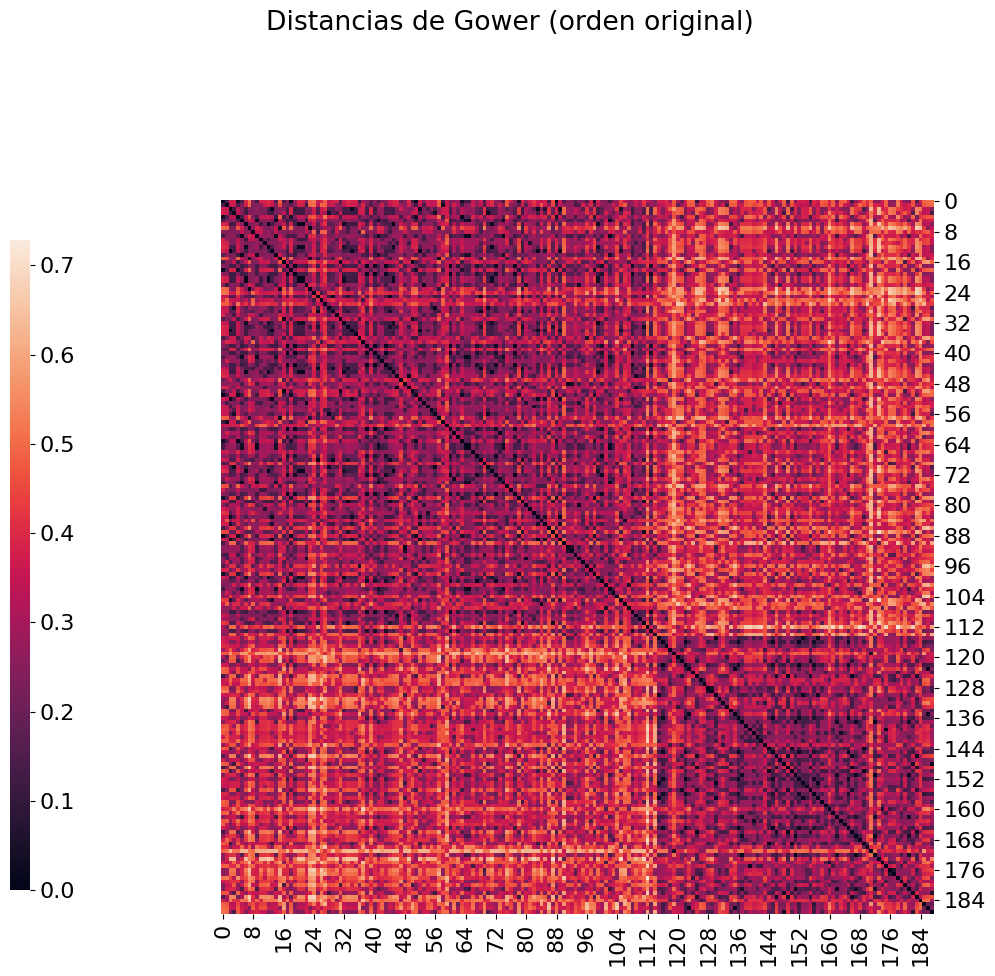

In [ ]:
d_meta = gower.gower_matrix(meta)
g = sns.clustermap(d_meta, row_cluster=False, col_cluster=False, cbar_pos=(0, .1, .02, .65))
plt.suptitle('Distancias de Gower (orden original)')
plt.show()

#### ¿Qué se puede decir de la presencia de grupos en el dataset?

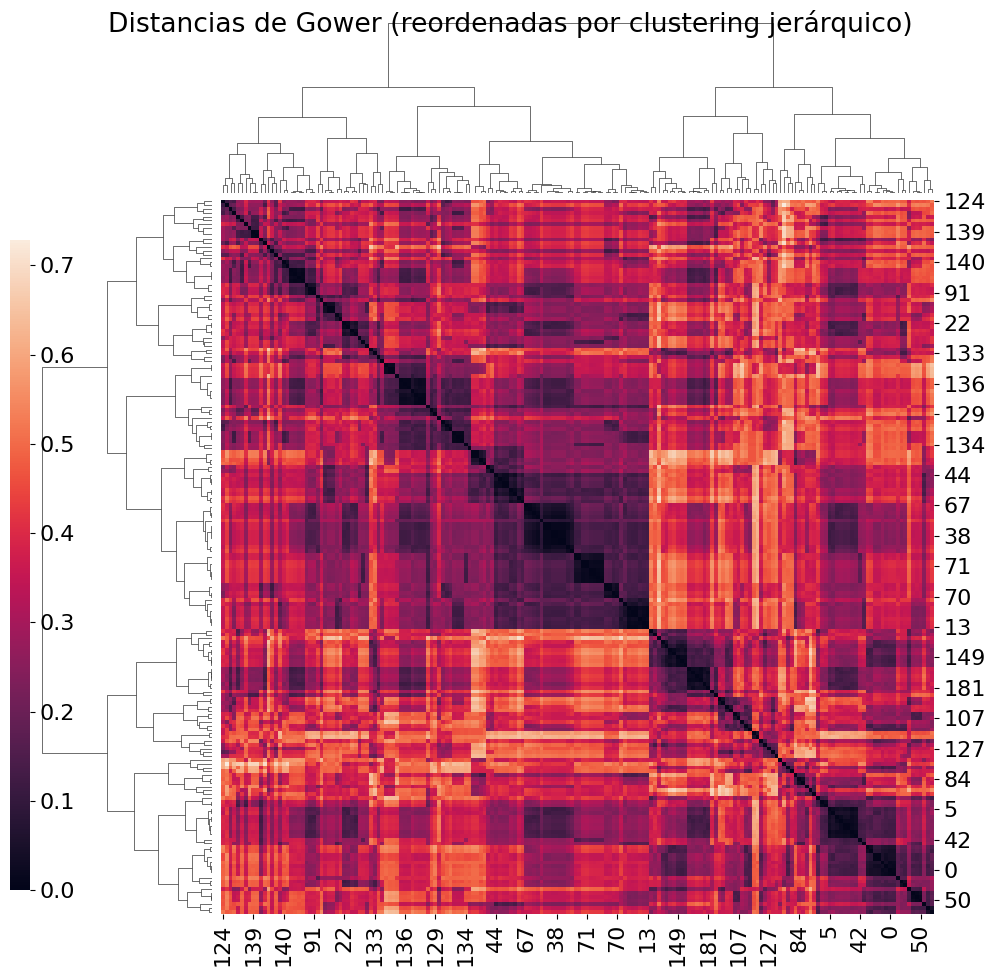

In [ ]:
# Para que el reordenamiento use las distancias de Gower (y no la euclídea entre los perfiles
# de distancia, que es lo que clustermap haría por defecto), le pasamos un linkage precomputado.
Z_meta = linkage(squareform(d_meta), method='ward')
g = sns.clustermap(d_meta, row_linkage=Z_meta, col_linkage=Z_meta, cbar_pos=(0, .1, .02, .65))
plt.suptitle('Distancias de Gower (reordenadas por clustering jerárquico)')
plt.show()

#### Jerárquico


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import squareform

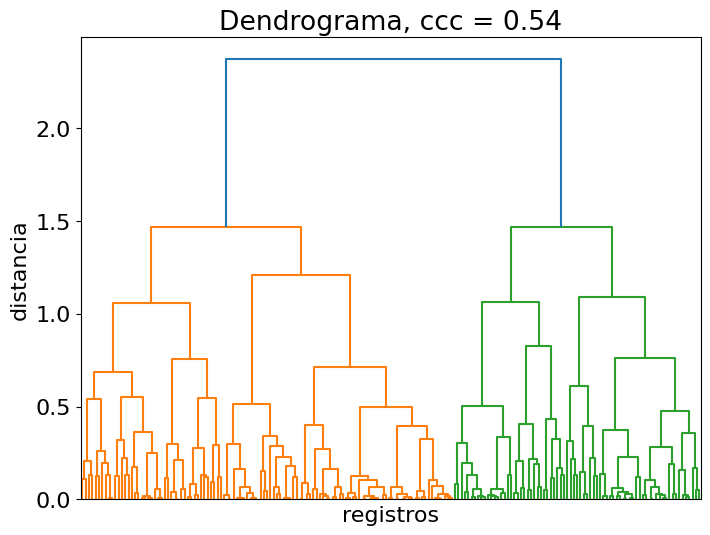

In [ ]:
c, _ = cophenet(Z_meta, Y=squareform(d_meta))
plt.title('Dendrograma, ccc = %0.2f' % c)
plt.xlabel('registros')
plt.ylabel('distancia')
dn = dendrogram(Z_meta, no_labels=True)

#### PAM
Para agrupar los datos datos vamos a usar el método PAM, y como desconocemos el mejor valor de K a utilizar, vamos a probar varios y después usar los gráficos de SSE vs. k y Silhouette vs. k.
En el loop de más abajo se recorren los valores de k desde 2 hasta el máximo número de k (cantidad de clusters) que se van a probar. En cada iteración se calcula un nuevo PAM y con sus medoides se calcula el SSE y Silhouette.

> **Nota sobre la implementación.** Usamos la librería [`kmedoids`](https://github.com/kno10/python-kmedoids), que implementa **FasterPAM** (Schubert & Rousseeuw, 2021): el mismo algoritmo PAM pero con una mejora de orden $O(k)$ por iteración, mucho más rápido y mantenido (a diferencia de `scikit-learn-extra`, ya discontinuado). La API es casi idéntica: `KMedoids(n_clusters=k, metric='precomputed', method='fasterpam', init='build').fit(D)` y expone `.labels_`, `.medoid_indices_` e `.inertia_`. Usamos `init='build'` (la inicialización BUILD clásica de PAM, que reemplaza a las opciones `'heuristic'`/`'k-medoids++'` de la librería anterior) y fijamos `random_state` para que el resultado sea reproducible.

In [ ]:
if IN_COLAB:
    !pip install -q kmedoids
from kmedoids import KMedoids
from sklearn.metrics import silhouette_samples, silhouette_score

In [ ]:
def calcula_sse_kmedoids(KM,d):
  # Suma de distancias AL CUADRADO a cada medoide (estilo SSE de k-means). Nota: el objetivo
  # que PAM realmente minimiza es la suma de disimilitudes SIN elevar al cuadrado, que la
  # librería expone directamente como KM.inertia_.
  se = []
  for i in range(0,KM.n_clusters):
    se.append(sum(d[KM.medoid_indices_[i],KM.labels_==i]**2))
  return sum(se)

In [ ]:
KM_meta = KMedoids(n_clusters=4, metric='precomputed', method='fasterpam',
                   init='build', random_state=0).fit(d_meta)

In [ ]:
print(KM_meta.labels_)
print(KM_meta.medoid_indices_)

[3 3 0 0 3 0 0 0 0 3 0 0 0 0 0 0 3 0 3 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 3
 0 0 3 0 3 3 0 0 0 0 3 0 0 3 3 0 0 0 0 0 0 3 3 0 3 0 3 3 3 0 0 0 3 0 0 0 3
 3 0 0 0 3 0 0 0 0 0 3 0 3 0 3 0 3 0 0 3 0 3 3 0 3 0 0 3 3 3 3 0 3 3 0 0 0
 0 3 0 3 2 2 2 1 1 1 1 2 2 2 1 1 1 2 2 2 1 1 1 2 2 2 1 2 2 2 1 2 1 2 2 1 2
 2 1 2 1 2 2 2 1 2 2 2 2 1 2 2 2 2 2 1 1 1 2 2 1 1 1 1 2 1 1 2 2 1 1 2 1 1
 2 2 2]
[ 19 149 116  88]


In [ ]:
print(silhouette_score(d_meta,KM_meta.labels_,metric='precomputed'))
print(calcula_sse_kmedoids(KM_meta,d_meta))
silhouette_samples(d_meta,KM_meta.labels_,metric='precomputed')

0.2729407
6.3253975


array([ 3.87980580e-01,  2.53809184e-01,  3.79267126e-01,  3.71944875e-01,
        3.67636472e-01, -9.86062661e-02,  4.08719689e-01,  3.72916728e-01,
        7.25912005e-02,  1.18251614e-01,  2.90996134e-01,  2.92694360e-01,
        3.98813426e-01,  3.81274641e-01, -4.84570228e-02,  3.63747269e-01,
        3.62332612e-01,  3.75897408e-01,  3.70443434e-01,  3.79756838e-01,
        4.05684352e-01,  4.07671869e-01,  1.90526426e-01,  3.72916728e-01,
        1.98907182e-01,  4.33213502e-01,  1.51984198e-02,  1.48039714e-01,
        3.53588462e-01,  4.19153780e-01,  2.60588050e-01,  3.59693170e-01,
        4.06899810e-01,  4.48476732e-01,  3.80308867e-01,  3.65383118e-01,
        3.38260621e-01, -3.04715168e-02,  3.75897408e-01,  2.05009803e-01,
        3.79756838e-01,  1.11974649e-01, -1.39835430e-03,  3.76940489e-01,
        4.52750087e-01,  4.07972723e-01,  3.37894380e-01,  2.55414248e-01,
        1.53684512e-01,  3.36721539e-01,  3.69051188e-01,  3.90979558e-01,
        3.82703006e-01,  

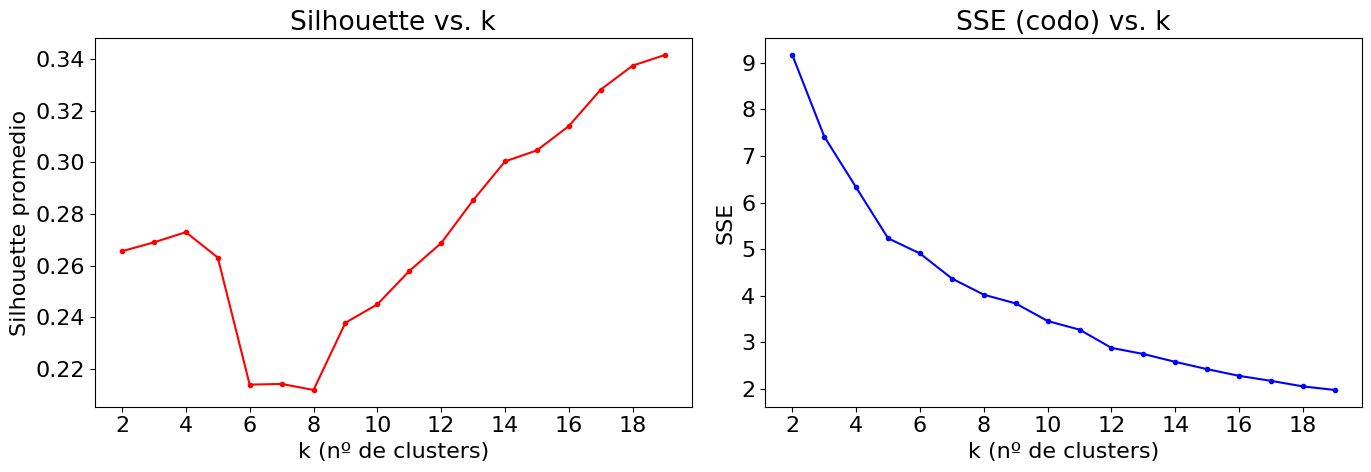

In [ ]:
range_k = list(range(2, 20))
silh, sse = [], []
for k in range_k:
    KM_meta = KMedoids(n_clusters=k, metric='precomputed', method='fasterpam',
                       init='build', random_state=0).fit(d_meta)
    silh.append(silhouette_score(d_meta, KM_meta.labels_, metric='precomputed'))
    sse.append(calcula_sse_kmedoids(KM_meta, d_meta))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range_k, silh, 'r.-')
ax1.set_xlabel('k (nº de clusters)'); ax1.set_ylabel('Silhouette promedio')
ax1.set_xticks(range_k[::2]) # Mostrar solo cada 2 para no amontonar
ax1.set_title('Silhouette vs. k')
ax2.plot(range_k, sse, 'b.-')
ax2.set_xlabel('k (nº de clusters)'); ax2.set_ylabel('SSE')
ax2.set_xticks(range_k[::2])
ax2.set_title('SSE (codo) vs. k')
plt.tight_layout(); plt.show()

#### ¿Cómo se interpretan estos gráficos?

Ayuda: mirar el cluster jerárquico que hicimos antes.

Probamos primero con k=10.

Función para graficar silouette

In [ ]:
def grafica_silhouette(KM,d):
  # Derivamos k del propio modelo en lugar de depender de una variable global 'k'.
  k = KM.n_clusters
  cmap = plt.get_cmap('nipy_spectral')
  silhouette_avg = silhouette_score(d,KM.labels_,metric='precomputed')
  sample_silhouette_values = silhouette_samples(d,KM.labels_,metric='precomputed')

  plt.rcParams['figure.figsize'] = (8,6)
  plt.xlim([-0.1, 1])
  plt.ylim([0, len(KM.labels_) + (k + 1) * 10])

  y_lower = 10
  for i in range(k):
      ith_cluster_silhouette_values = sample_silhouette_values[KM.labels_ == i]

      ith_cluster_silhouette_values.sort()

      size_cluster_i = ith_cluster_silhouette_values.shape[0]
      y_upper = y_lower + size_cluster_i

      color = cmap(float(i) / k)
      plt.fill_betweenx(np.arange(y_lower, y_upper),
                        0, ith_cluster_silhouette_values,
                        facecolor=color, edgecolor=color, alpha=0.7)

      plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

      y_lower = y_upper + 10

  plt.title("Análisis de silhouette para clustering con k = %d" % k,
                fontsize=14, fontweight='bold')
  plt.xlabel("Coeficiente de silhouette")
  plt.ylabel("Etiquetas de cluster")

  # La línea vertical marca el coeficiente de silhouette promedio
  plt.axvline(x=silhouette_avg, color="red", linestyle="--")

  plt.yticks([])  # Clear the yaxis labels / ticks
  plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
  plt.show()

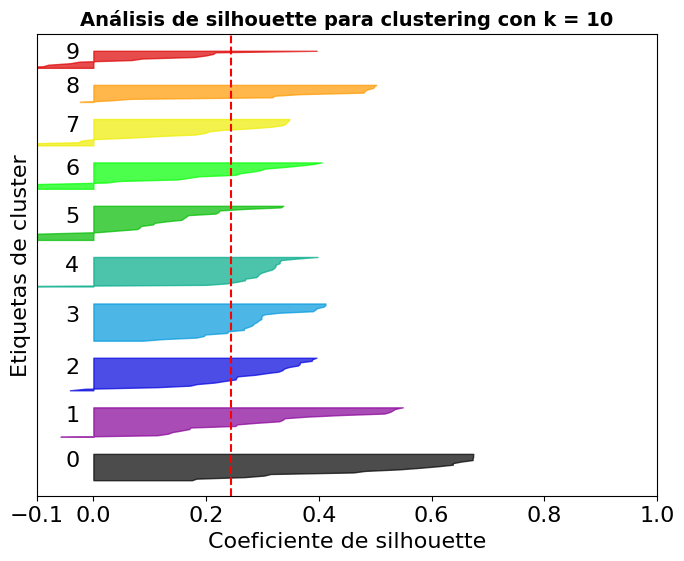

In [ ]:
k = 10
KM_meta = KMedoids(n_clusters=k, metric='precomputed', method='fasterpam',
                   init='build', random_state=0).fit(d_meta)
grafica_silhouette(KM_meta,d_meta)

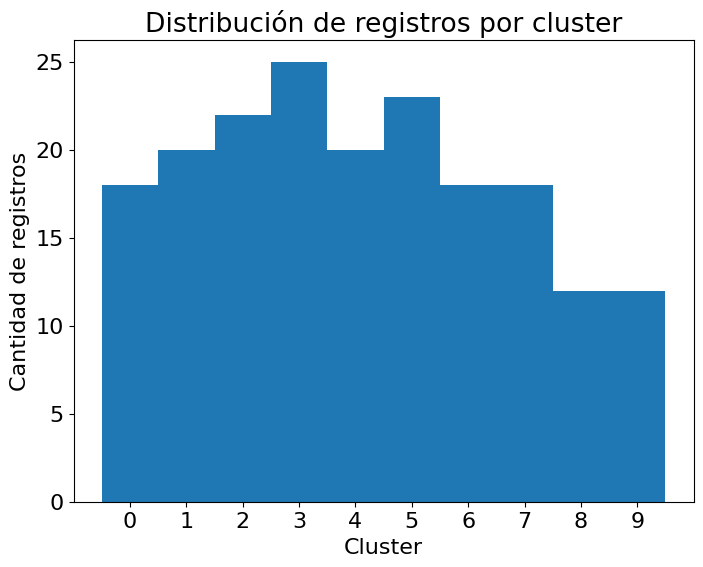

In [ ]:
plt.hist(KM_meta.labels_,bins=k,range=[-0.5,k-0.5])
plt.xticks(np.arange(0,k))
plt.xlabel('Cluster')
plt.ylabel('Cantidad de registros')
plt.title('Distribución de registros por cluster')
plt.show()

In [ ]:
np.unique(KM_meta.labels_, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint64),
 array([18, 20, 22, 25, 20, 23, 18, 18, 12, 12]))

In [ ]:
KM_meta.medoid_indices_

array([ 38, 149, 122,  51,  79,   9, 130,  89,  21, 126], dtype=uint64)

Veamos los valores que toman los prototipos

In [ ]:
meta.iloc[KM_meta.medoid_indices_]

,AGE,GENDER,DOMAIN,PhD,YEARSEXP,OTHERSTATUS,USERWIKI
268,41,M,Political_Sciences,Y,15,2,N
653,38,F,Political_Sciences,N,7,7,N
554,43,F,Political_Sciences,Y,20,2,N
307,41,M,Political_Sciences,N,12,7,N
411,44,M,Engineering_Architecture,Y,22,2,N
178,41,M,Political_Sciences,Y,10,7,N
586,36,F,Political_Sciences,Y,10,4,N
441,42,M,Law,Y,16,2,N
213,48,M,Sciences,Y,20,2,N
568,47,F,Arts_Humanities,N,5,6,N


Para este ejercicio nos quedamos con k=4, que no es necesariamente el mejor valor.

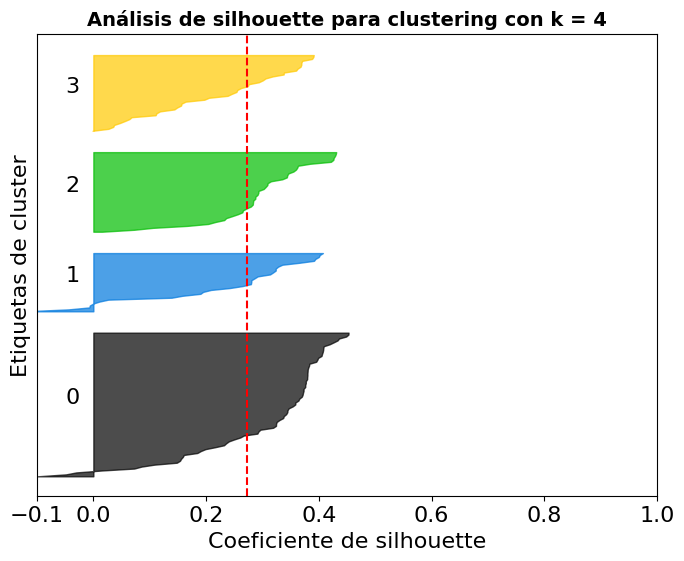

In [ ]:
k = 4
KM_meta = KMedoids(n_clusters=k, metric='precomputed', method='fasterpam',
                   init='build', random_state=0).fit(d_meta)
grafica_silhouette(KM_meta,d_meta)

In [ ]:
meta.iloc[KM_meta.medoid_indices_]

,AGE,GENDER,DOMAIN,PhD,YEARSEXP,OTHERSTATUS,USERWIKI
211,42,M,Political_Sciences,Y,18,2,N
653,38,F,Political_Sciences,N,7,7,N
534,42,F,Political_Sciences,Y,18,2,N
438,42,M,Political_Sciences,N,8,7,N


#### Perfil de los clusters
El medoide es solo el registro más representativo de cada grupo. Para entender **qué distingue** a los clusters conviene mirar la distribución de cada variable por grupo. Fijate cómo el género y los años de experiencia (`YEARSEXP`) separan los grupos, algo que el medoide por sí solo —que cae siempre en la categoría de dominio más frecuente— no dejaba ver.

In [ ]:
perfil = meta.assign(cluster=KM_meta.labels_)
display(perfil.groupby('cluster')[['AGE', 'YEARSEXP']].mean().round(1))
for col in ['GENDER', 'PhD', 'USERWIKI', 'DOMAIN']:
    print('\n\nDistribución de %s por cluster:' % col)
    display(pd.crosstab(perfil['cluster'], perfil[col]))

,AGE,YEARSEXP
cluster,,
0,43.2,16.5
1,39.9,8.7
2,41.5,15.8
3,41.6,9.8




Distribución de GENDER por cluster:


GENDER,F,M
cluster,,
0,0,75
1,31,0
2,42,0
3,0,40




Distribución de PhD por cluster:


PhD,N,Y
cluster,,
0,1,74
1,24,7
2,1,41
3,27,13




Distribución de USERWIKI por cluster:


USERWIKI,N,Y
cluster,,
0,66,9
1,28,3
2,39,3
3,34,6




Distribución de DOMAIN por cluster:


DOMAIN,Arts_Humanities,Engineering_Architecture,Health_Sciences,Law,Political_Sciences,Sciences
cluster,,,,,,
0,7,19,4,12,24,9
1,7,0,3,3,18,0
2,6,1,5,9,20,1
3,3,2,4,8,22,1


#### Visualizar los clusters en 2D
Las distancias viven en un espacio de muchas dimensiones. Para *ver* los grupos proyectamos la matriz de distancias a 2D con **MDS** (*Multidimensional Scaling*), que ubica cada registro tratando de preservar las distancias originales, y coloreamos por cluster.

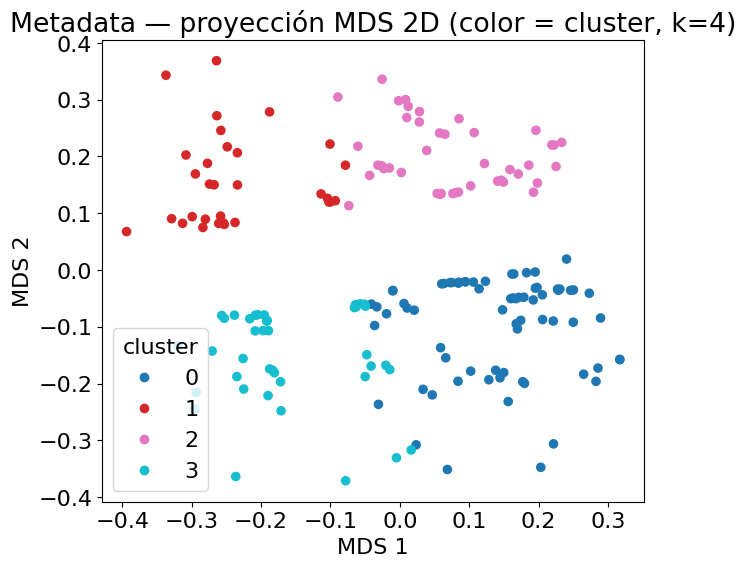

In [ ]:
from sklearn.manifold import MDS
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')  # MDS está migrando su API entre versiones de sklearn
    emb = MDS(n_components=2, dissimilarity='precomputed', random_state=0).fit_transform(d_meta)
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], c=KM_meta.labels_, cmap='tab10', s=35)
plt.legend(*sc.legend_elements(), title='cluster')
plt.title('Metadata — proyección MDS 2D (color = cluster, k=4)')
plt.xlabel('MDS 1'); plt.ylabel('MDS 2'); plt.show()

# Encuestas

## Análisis de las respuestas a las encuestas
Primero realicemos un cluster con el método PAM usando las distancias Euclideas entre respuestas.

In [ ]:
encu.head()

,PU1,PU2,PU3,PEU1,PEU2,ENJ1,ENJ2,Qu1,Qu2,Qu3,...,BI2,Inc1,Inc2,Inc3,Inc4,Exp1,Exp2,Exp3,Exp4,Exp5
148,5.0,5.0,5.0,5.0,4.0,5.0,4.0,4.0,4.0,4.0,...,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,2.0,4.0
149,3.0,2.0,2.0,4.0,4.0,2.0,3.0,3.0,3.0,3.0,...,3.0,4.0,4.0,3.0,4.0,2.0,3.0,4.0,1.0,2.0
160,2.0,2.0,1.0,4.0,3.0,2.0,3.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,1.0,1.0
164,3.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,3.0,3.0,...,3.0,3.0,5.0,3.0,3.0,2.0,3.0,1.0,1.0,1.0
165,4.0,4.0,3.0,5.0,5.0,4.0,4.0,3.0,4.0,2.0,...,3.0,4.0,4.0,5.0,3.0,4.0,4.0,4.0,2.0,3.0


In [ ]:
encu.dtypes

,0
PU1,float64
PU2,float64
PU3,float64
PEU1,float64
PEU2,float64
ENJ1,float64
ENJ2,float64
Qu1,float64
Qu2,float64
Qu3,float64


In [ ]:
np_encu = encu.to_numpy().astype(int)

k = 2
KM_encu_eucl = KMedoids(n_clusters=k, metric='euclidean', method='fasterpam',
                        init='build', random_state=0).fit(np_encu)
KM_encu_eucl.labels_

array([1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1], dtype=uint64)

In [ ]:
from sklearn.metrics import pairwise_distances
d_encu_eucl = pairwise_distances(np_encu, metric='euclidean')
print(calcula_sse_kmedoids(KM_encu_eucl, d_encu_eucl))
print(silhouette_score(d_encu_eucl, KM_encu_eucl.labels_, metric='precomputed'))
# Nota: el SSE no es comparable entre métricas distintas (la euclídea y la categórica
# normalizada están en escalas diferentes); el silhouette sí permite compararlas.

8588.0
0.16022771737128388


### Una función de distancia para variables categóricas ordenadas.
Las respuestas están codificadas con cinco valores enteros ordenados. En consecuencia, en lugar de la distancia euclídea, podríamos usar alguna de distancia para variables categóricas ordenadas, como la que vimos en la teórica de medidas de (di)similitud. Para normalizar las distancias entre 0 y 1, vamos a tener en cuenta que el máximo valor de disimilitud es la máxima diferencia entre respuestas, 5-1 = 4

In [ ]:
# Disimilitud para variables categóricas ordenadas = suma de |diferencias| entre respuestas
# (distancia Manhattan), normalizada por el máximo posible de disimilitud:
#   norm = nro_de_columnas * (max - min) de la escala (= 5 - 1 = 4).
norm = encu.shape[1] * (np_encu.max() - np_encu.min())

d_encu_cat = pairwise_distances(np_encu, metric='manhattan') / norm

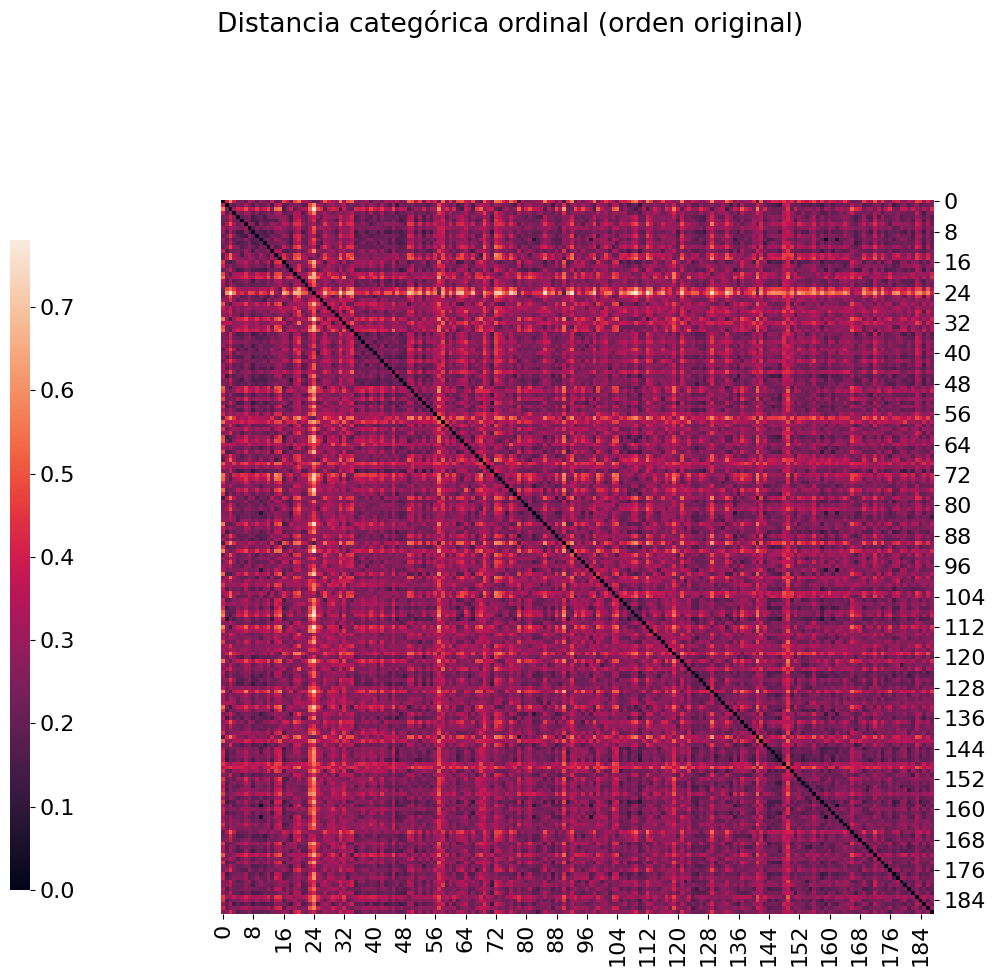

In [ ]:
g = sns.clustermap(d_encu_cat, row_cluster=False, col_cluster=False, cbar_pos=(0, .1, .02, .65))
plt.suptitle('Distancia categórica ordinal (orden original)')
plt.show()

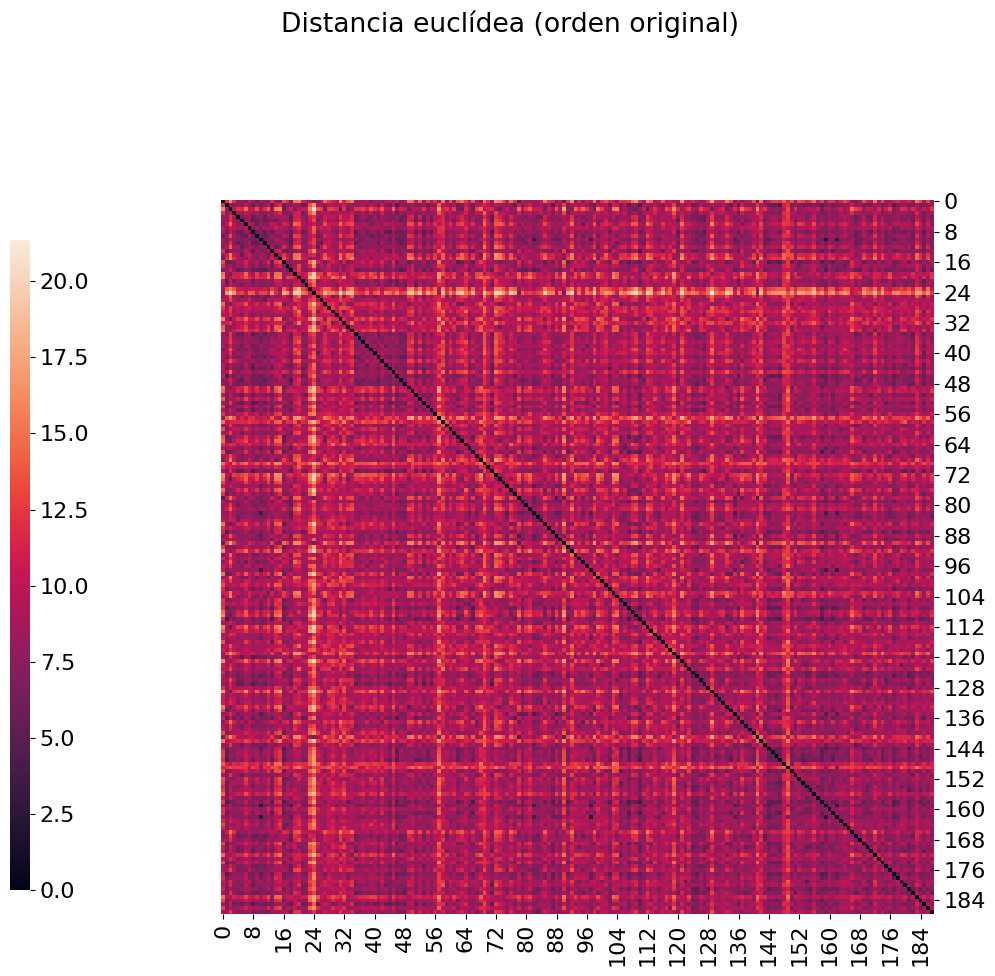

In [ ]:
g = sns.clustermap(d_encu_eucl, row_cluster=False, col_cluster=False, cbar_pos=(0, .1, .02, .65))
plt.suptitle('Distancia euclídea (orden original)')
plt.show()

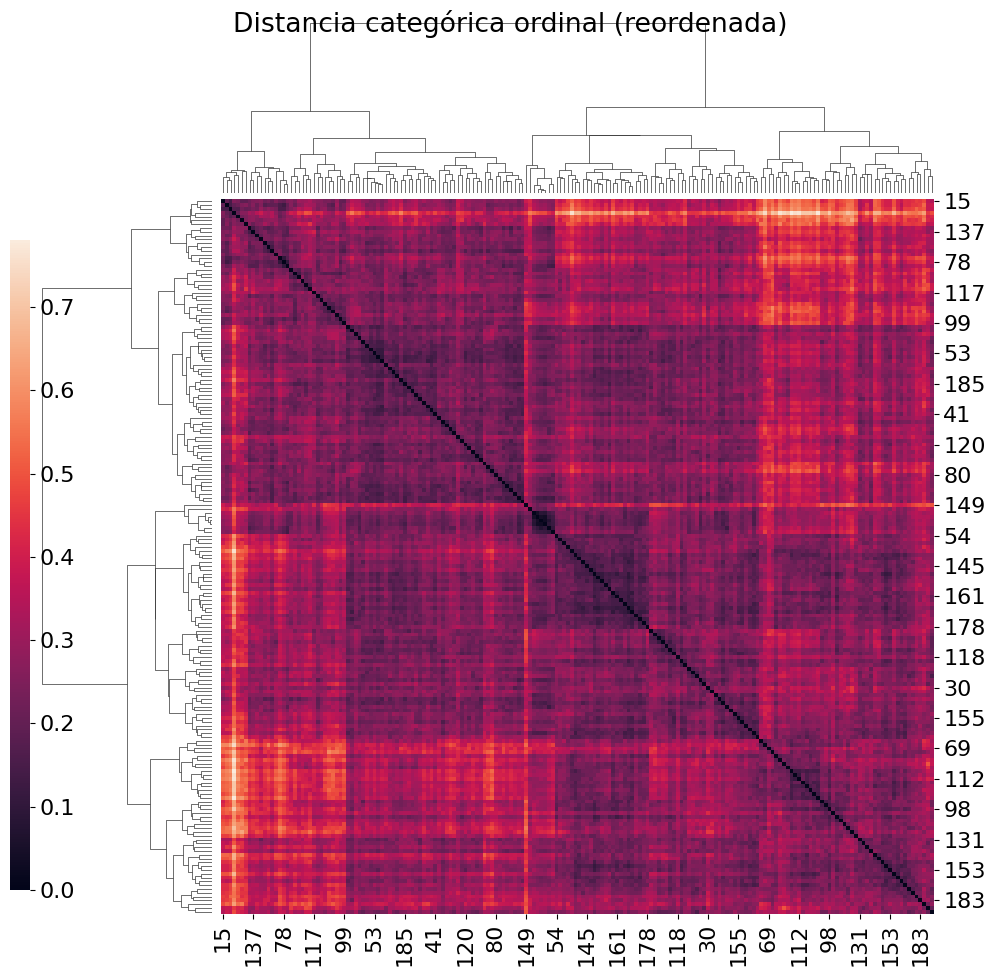

In [ ]:
Z_cat = linkage(squareform(d_encu_cat), method='ward')
g = sns.clustermap(d_encu_cat, row_linkage=Z_cat, col_linkage=Z_cat, cbar_pos=(0, .1, .02, .65))
plt.suptitle('Distancia categórica ordinal (reordenada)')
plt.show()

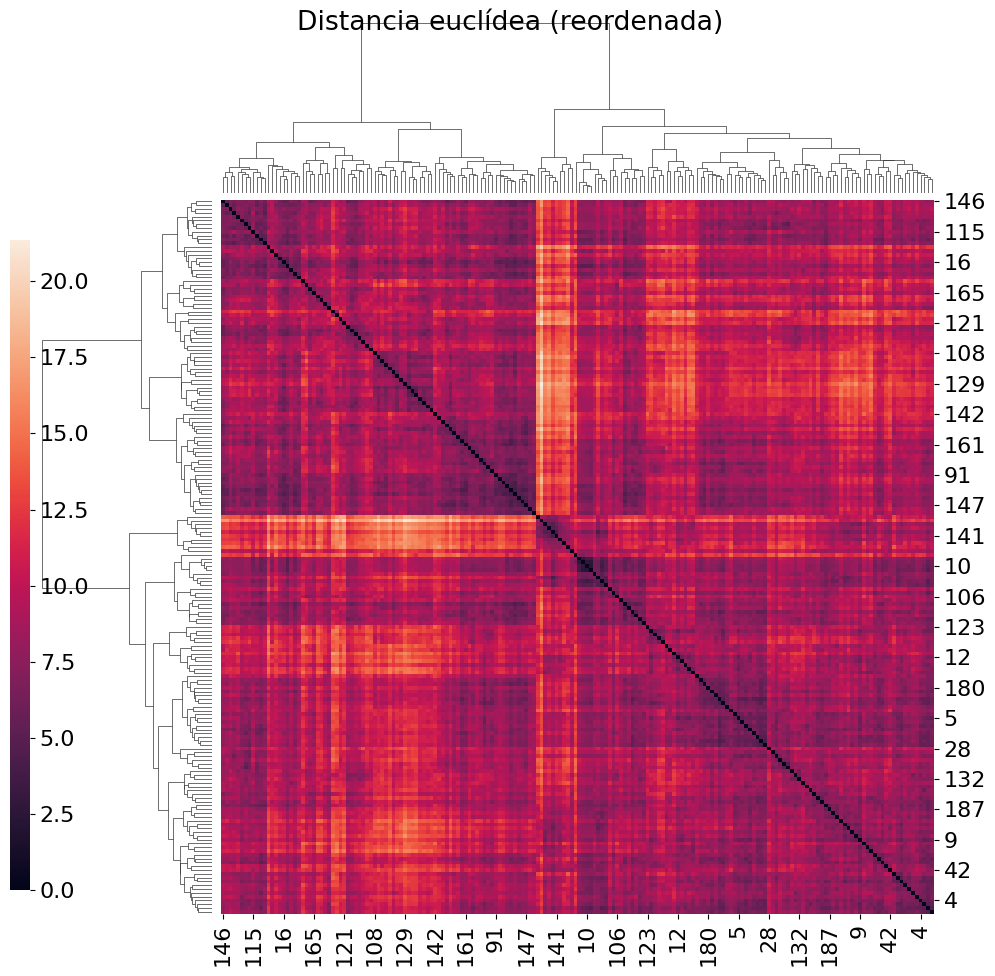

In [ ]:
Z_eucl = linkage(squareform(d_encu_eucl), method='ward')
g = sns.clustermap(d_encu_eucl, row_linkage=Z_eucl, col_linkage=Z_eucl, cbar_pos=(0, .1, .02, .65))
plt.suptitle('Distancia euclídea (reordenada)')
plt.show()

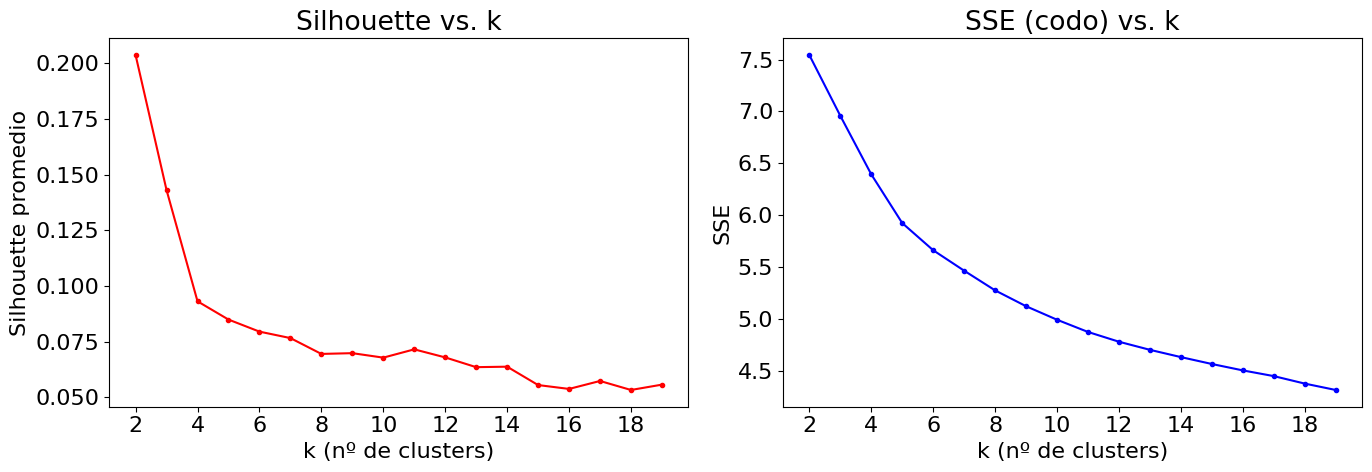

In [ ]:
#d_encu_cat

range_k = list(range(2, 20))
silh, sse = [], []
for k in range_k:
    KM_encu_cat = KMedoids(n_clusters=k, metric='precomputed', method='fasterpam',
                           init='build', random_state=0).fit(d_encu_cat)
    silh.append(silhouette_score(d_encu_cat, KM_encu_cat.labels_, metric='precomputed'))
    sse.append(calcula_sse_kmedoids(KM_encu_cat, d_encu_cat))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range_k, silh, 'r.-')
ax1.set_xlabel('k (nº de clusters)'); ax1.set_ylabel('Silhouette promedio')
ax1.set_xticks(range_k[::2]) # Mostrar solo cada 2 para no amontonar
ax1.set_title('Silhouette vs. k')
ax2.plot(range_k, sse, 'b.-')
ax2.set_xlabel('k (nº de clusters)'); ax2.set_ylabel('SSE')
ax2.set_xticks(range_k[::2])
ax2.set_title('SSE (codo) vs. k')
plt.tight_layout(); plt.show()

6.394742712671029
0.0931179859139689


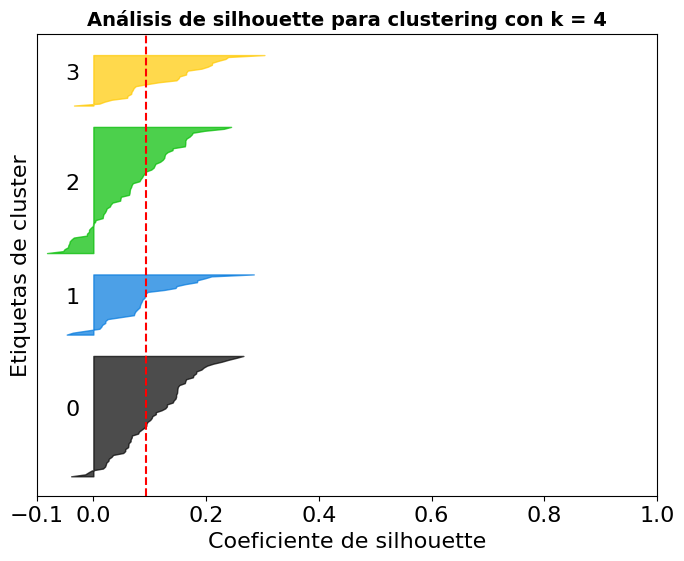

In [ ]:
k = 4
KM_encu_cat = KMedoids(n_clusters=k, metric='precomputed', method='fasterpam',
                       init='build', random_state=0).fit(d_encu_cat)
print(calcula_sse_kmedoids(KM_encu_cat,d_encu_cat))
print(silhouette_score(d_encu_cat,KM_encu_cat.labels_,metric='precomputed'))
grafica_silhouette(KM_encu_cat,d_encu_cat)

#### Las encuestas en 2D
Lo mismo para la partición de las respuestas a la encuesta (k=2).

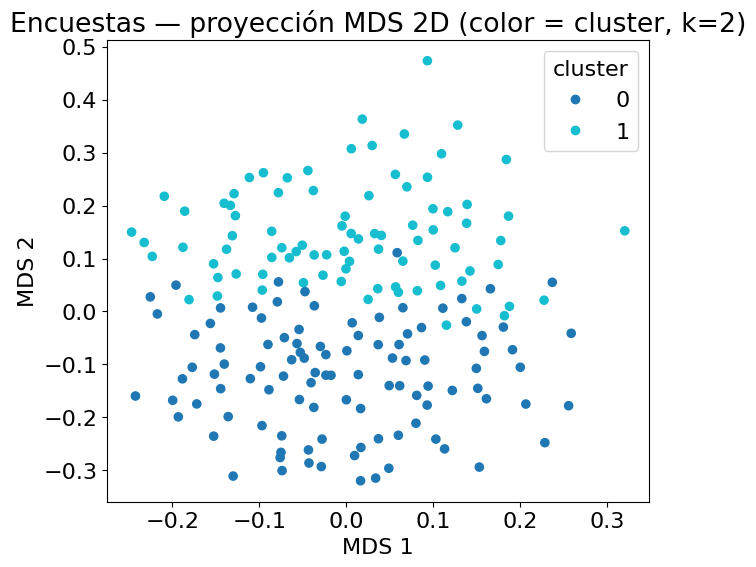

In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    emb_e = MDS(n_components=2, dissimilarity='precomputed', random_state=0).fit_transform(d_encu_cat)
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb_e[:, 0], emb_e[:, 1], c=KM_encu_cat.labels_, cmap='tab10', s=35)
plt.legend(*sc.legend_elements(), title='cluster')
plt.title('Encuestas — proyección MDS 2D (color = cluster, k=2)')
plt.xlabel('MDS 1'); plt.ylabel('MDS 2'); plt.show()

# Ahora comparamos los clusterings de ambos conjuntos (Metadata y respuesta a Encuestas)

In [ ]:
tmp = pd.DataFrame({'Meta': KM_meta.labels_, 'Encu': KM_encu_cat.labels_})
ct = pd.crosstab(tmp['Meta'], tmp['Encu'])
ct

Encu,0,1,2,3
Meta,,,,
0,18,12,33,12
1,11,8,8,4
2,26,4,9,3
3,8,8,16,8


In [ ]:
def vanDongen(ct):
    # ct es la tabla de contingencia entre las dos particiones.
    n2 = 2 * ct.to_numpy().sum()
    sumi = ct.max(axis=1).sum()      # suma de los máximos por fila
    sumj = ct.max(axis=0).sum()      # suma de los máximos por columna
    maxsumi = ct.sum(axis=1).max()   # mayor total de fila
    maxsumj = ct.sum(axis=0).max()   # mayor total de columna
    return (n2 - sumi - sumj) / (n2 - maxsumi - maxsumj)

In [ ]:
from sklearn.metrics import adjusted_rand_score

In [ ]:
print("Van Dongen para la partición generada con el clustering PAM para los datos meta y las encuestas es de %0.4f." % vanDongen(ct))
print("ARI para la partición generada con el clustering PAM para los datos meta y las encuestas es de %0.4f." % adjusted_rand_score(KM_meta.labels_, KM_encu_cat.labels_))

Van Dongen para la partición generada con el clustering PAM para los datos meta y las encuestas es de 0.8809.
ARI para la partición generada con el clustering PAM para los datos meta y las encuestas es de 0.0370.


#### ¿Qué nos dicen estos números?
El **índice de Rand ajustado (ARI)** vale ~0 cuando las dos particiones coinciden solo lo que cabría esperar por azar, y 1 cuando son idénticas. El **índice de Van Dongen** es 0 si las particiones son idénticas y crece hacia 1 cuanto más difieren.

Acá obtenemos un ARI cercano a 0 y un Van Dongen cercano a 1: **la forma en que se agrupan los encuestados según sus datos demográficos es prácticamente independiente de cómo se agrupan según sus patrones de uso y opinión sobre Wikipedia.** Conocer el perfil demográfico de una persona no permite anticipar su patrón de respuestas, y viceversa.

# Propuesta: Tomar MNIST o algún dataset que decidan y proponer alguna clusterización usando K-medoids y/o clustering jerárquico
Utilizar también PCA, UMAP o algún método para reducir la dimensionalidad y otro para su validación interna y externa

In [ ]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import scale

In [ ]:
clases = 1

digits = load_digits(n_class=clases)
X2 = digits.data
X2 = scale(X2)
y2 = digits.target